In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Problem 1
Consider a causal system given by the following system function
$$
H(z) = 1 + 3.5z^{-1} + 1.5z^{-2}
$$
and assume that the causal system is used as a model for a communication channel that
will distort signals passing through it.

### 1. Design an equalizer that can mitigate the distortion.

To design an equalizer we first have to determine what kind of system we are dealing with by analyzing the zeros of the system. We can factor the system function as follows:
\begin{align*}
H(z) &= 1 - ((-3)+(-0.5))z^{-1} + (-3)(-0.5)z^{-2}\\
&= (1 - (-3)z^{-1}) (1 - (-0.5)z^{-1})\\
&= (1 + 3z^{-1}) (1 + 0.5z^{-1})
\end{align*}

In this form it can be seen that there is a zero at $z = -3$ and $z = -0.5$. The zero at $z = -3$ is outside the unit circle meaning that it is a mixed-phase system. An equalizer is the inverse of the system but inverting any nonminimum-phase system will result in an unstable system. To avoid this we have to reflect the zero outside the unit circle inside the unit circle. To not affect the magnitude response during inversino, we have to find a corresponding all-pass system that cancels out the effect on the magnitude response. This is done using equation (5.174) as follows:
\begin{align*}
H(z) &= 3 \left( z^{-1} + \frac{1}{3} \right) (1 + 0.5z^{-1})\\
&= 3 \left( z^{-1} + \frac{1}{3} \right) (1 + 0.5z^{-1}) \frac{1 + \frac{1}{3}z^{-1}}{1 + \frac{1}{3} z^{-1}}\\
&=  \underbrace{3\left( 1 + \frac{1}{3} z^{-1} \right) (1 + 0.5z^{-1})}_{H_{\min}(z)} \underbrace{\frac{z^{-1} + \frac{1}{3}}{1 + \frac{1}{3} z^{-1}}}_{H_{\text{ap}}(z)}
\end{align*}

This decomposition yields a minimum phase system that can be inverted to get the equalizer following equation (5.187). The all-pass system part is not relevant since it has a magnitude response of 1.
\begin{align*}
H_{eq}(z) &= \frac{1}{H_{\min}(z)}\\
&= \frac{1}{3\left( 1 + \frac{1}{3} z^{-1} \right) (1 + 0.5z^{-1})}\\
&= \frac{1}{(3 + 1z^{-1})(1 + 0.5z^{-1})}\\
&= \frac{1}{3 + 1.5z^{-1} + 1z^{-1} + 0.5z^{-2}}\\
&= \frac{1}{3 + 2.5z^{-1} + 0.5z^{-2}}
\end{align*}

### 2. Make a time-domain simulation of the system and the equalizer using a test signal of your choice. Explain the choice of test signal and procedures, present plots, and analyze the performance of the equalizer.

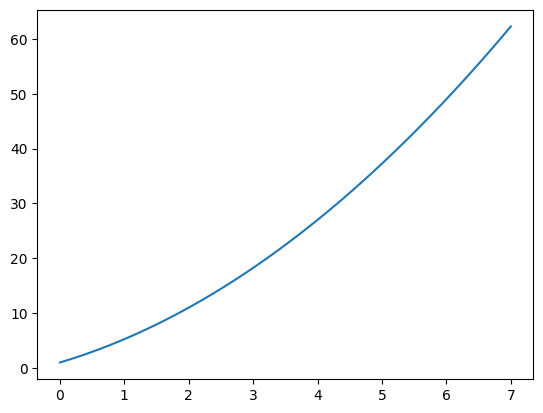

In [2]:
num = [1, 3.5, 1.5]
den = [1, 0, 0]
H = signal.lti(num, den)
t, x = signal.step(H)
plt.plot(t, x)

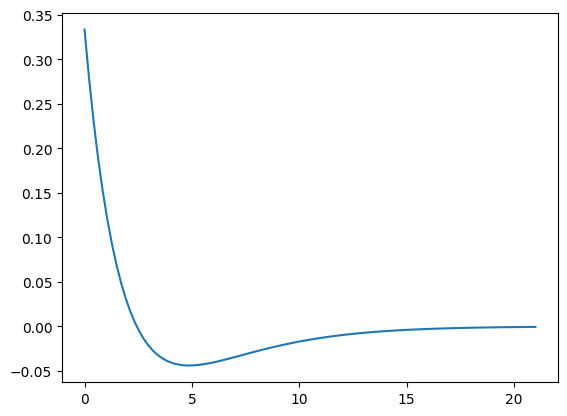

In [3]:
num = [1, 0, 0]
den = [3, 2.5, 0.5]
H_equalizer = signal.lti(num, den)
t, x_equalizer = signal.step(H_equalizer)
plt.plot(t, x_equalizer)

In [4]:
# H_equalized = signal.lti(signal.lfilter(num, den, x))
# t, x_equalized = signal.step(H_equalized)
# plt.plot(t, x_equalized)

### 3. Next, assume that after the signal has passed through the communication channel is it further distorted by additive white Gaussian noise before it enters the equalizer designed above. How are the results affected by the additive noise?

## Problem 2
Consider the random process $x[n]$ created as $x[n] = 4w[n] − 2w[n − 3]$ where $w[n]$ is unit
variance white Gaussian noise.

### 1. Compute an analytic expression for the autocorrelation $r_{xx}[l]$.

Since the process is a linear combination of white Gaussian noise, assuming it is also zero mean, the autocorrelation can be computed as follows:
\begin{align*}
r_{xx}[l] &= E(x[n]x[n-l])\\
&= E((4w[n] - 2w[n - 3])(4w[n - l] - 2w[(n - l) - 3]))\\
&= E(16w[n]w[n - l] - 8w[n]w[n - l - 3] - 8w[n - 3]w[n - l] + 4w[n - 3]w[n - l - 3])\\
&= 16E(w[n]w[n - l]) - 8E(w[n]w[n - l - 3]) - 8E(w[n - 3]w[n - l]) + 4E(w[n - 3]w[n - l - 3])
\end{align*}

An expected values of the form $E[w[n]w[n - l]]$ equates to the autocorrelation of the white Gaussian noise $r_{ww}[l]$, again assuming that we are working with zero mean Gaussian noise. Only one of the terms follow this exact form, the others have additional time lag. Since the autocorrelation depends on lag the relative lag for each term can be computed and then set as the input for $r_{ww}[l]$. The lag for each term can be computed as follows:

$$
n - (n - l) = l
$$
$$
n - (n - l - 3) = l + 3
$$
$$
n - 3 - (n - l) = l - 3
$$
$$
n - 3 - (n - l - 3) = l
$$

$r_{ww}[l]$ can then inserted into the equation above along with these lags. Given that $w[n]$ has unit variance, $\sigma^2 = 1$, the autocorrelation, $r_{ww}[l]$, can be substituted by $\delta[l]$.

\begin{align*}
r_{xx}[l] &= 16r_{ww}[l] - 8r_{ww}[l+3] - 8r_{ww}[l-3] + 4r_{ww}[l]\\
&= 16\delta[l] - 8\delta[l+3] - 8\delta[l-3] + 4\delta[l]\\
&= 20\delta[l] - 8\delta[l+3] - 8\delta[l-3]
\end{align*}

### 2. Plot the power spectral density of the random process. What can be learned from the plot?

The power spectral density is found as the Fourier transform of the ACRS following equation (13.112):
\begin{align*}
S_{xx}(\omega) &= \sum_{l = -\infty}^{\infty} r_{xx}[l] e^{ -jl\omega }\\
&= 20 e^{ j 0 \omega} - 8 e^{ j 3 \omega} - 8 e^{ j (-3) \omega}\\
&= 20 - 8e^{ j (3 \omega) } - 8e^{ -j (3\omega) }\\
&= 20 - 8 \left( e^{ j (3 \omega) } + e^{ -j (3\omega) } \right)\\
&= 20 - 8 \left( 2\cos(3\omega) \right)\\
&= 20 - 16\cos(3\omega)
\end{align*}

It can then be plotted using using python.

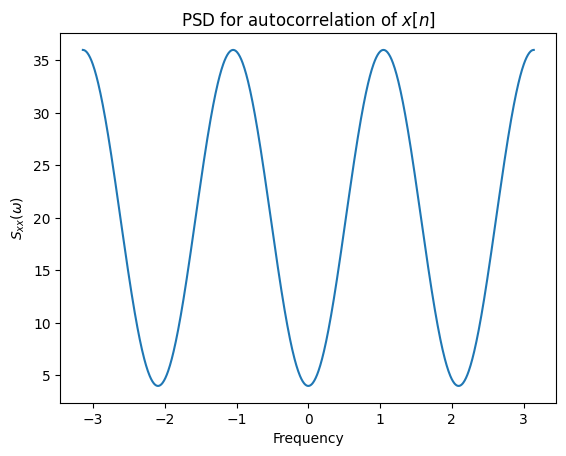

In [5]:
omega = np.linspace(-np.pi, np.pi, 1000)
S_xx = 20 - 16 * np.cos(3 * omega)
plt.plot(omega, S_xx)
plt.title('PSD for autocorrelation of $x[n]$')
plt.xlabel('Frequency')
plt.ylabel('$S_{xx}(\\omega)$')
plt.show()

### 3. Assume $x[n]$ is filtered through a FIR filter with $H(z) = 5 + z^{−1}$. Compute the analytic expressions for $r_{yx}[l]$ and $r_{yy}[l]$

The FIR filter can be expressed in the time domain as follows:
$$
h[n] = 5\delta[n] + \delta[n-1]
$$

Since it is only made up of scalar multiplication and time shifting it is a LTI system. The cross-correlation can then be computed with equation (13.100) as follows:
\begin{align*}
r_{yx}[l] &= h[l] * r_{xx}[l]\\
&= 5r_{xx}[l] + r_{xx}[l-1]\\
&= 5 \cdot (20\delta[l] - 8\delta[l+3] - 8\delta[l-3]) + 20\delta[l - 1] - 8\delta[(l - 1) + 3] - 8\delta[(l - 1) - 3]\\
&= 100\delta[l] - 40\delta[l + 3] - 40 \delta[l - 3] + 20\delta[l - 1] - 8\delta[l + 2] - 8 \delta[l - 4]
\end{align*}

The autocorrelation of $y[n]$ can then be calculated using equation (13.104). To do that the autocorrelation of the filter first has to be computed with equation (13.103):
\begin{align*}
r_{hh}[m] &= h[-m] * h[m]\\
&= 5h[m] + h[m + 1]\\
&= 5 \cdot (5\delta[m] + \delta[m - 1]) + 5\delta[m + 1] + \delta[(m + 1) - 1]\\
&= 25\delta[m] + 5\delta[m - 1] + 5\delta[m + 1] + \delta[m]\\
&= 26\delta[m] + 5\delta[m - 1] + 5\delta[m + 1]
\end{align*}

This can then be inserted alongside $r_{xx}[l]$ into equation (13.104) to get the autocorrelation of $y[n]$:
\begin{align*}
r_{yy}[l] &= r_{hh}[l] * r_{xx}[l]\\
&= 26r_{xx}[l] + 5r_{xx}[l - 1] + 5r_{xx}[l + 1]\\
&= 26 \cdot (20\delta[l] - 8\delta[l+3] - 8\delta[l-3]) + \\
&\quad 5 \cdot (20\delta[(l-1)] - 8\delta[(l-1)+3] - 8\delta[(l-1)-3]) + \\
&\quad 5 \cdot (20\delta[(l+1)] - 8\delta[(l+1)+3] - 8\delta[(l+1)-3])\\
&= 520\delta[l] - 208\delta[l+3] - 208\delta[l-3] + 100\delta[l-1] - 40\delta[l+2] - 40\delta[l-4] + 100\delta[l+1] - 40\delta[l+4] - 40\delta[l-2]
\end{align*}

Which can also be expressed as follows:
$$
r_{yy}[l] =
\begin{cases}
520 & l=0 \\
100 & l=\pm 1 \\
-40 & l=\pm 2, \pm 4 \\
-208 & l=\pm 3 \\
0 & \text{elsewhere}
\end{cases}
$$

## Problem 3
Let a signal and interpolation kernel be given by
$$
x[n] = 
\begin{cases}
2 & n = 0\\
1 & n = 1\\
0, & \text{elsewhere}
\end{cases}

\quad \text{ and } \quad

g[n] = 
\begin{cases}
-1 & n = -1\\
3 & n = 0\\
-1 & n = 1\\
0 & \text{elsewhere}
\end{cases}
$$

### 1. Upsample $x[n]$ by a factor of 3 and sketch the upsampled signal.

Upsampling by a factor of 3 means that we insert 2 zeros between each of the samples of $x[n]$ resulting in the following signal:
$$
x_{\text{u}}[n] =
\begin{cases}
2 & n = 0\\
1 & n = 3\\
0 & \text{elsewhere}
\end{cases}
$$

This can be plotted using python

Text(0, 0.5, '$x_{\\text{u}}[n]$')

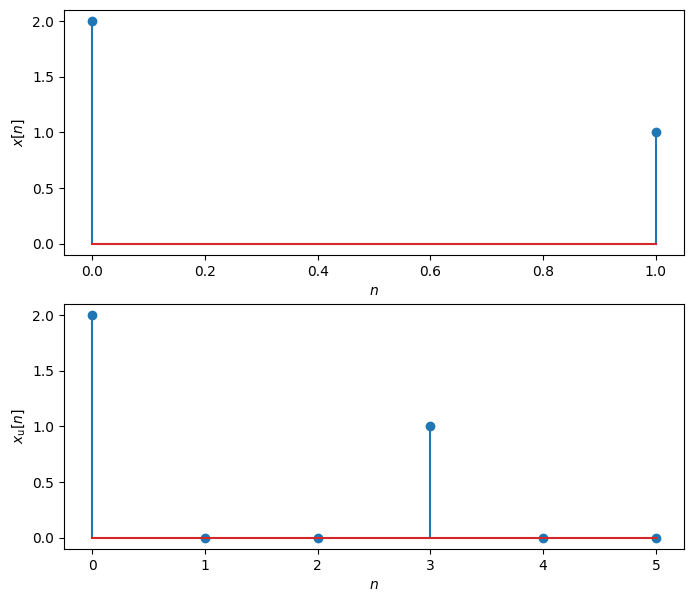

In [11]:
n = np.arange(0, 2, 1)
x = [2, 1]
fig, ax = plt.subplots(2, 1, figsize=(8, 7))
ax[0].stem(n, x)
ax[0].set_xlabel('$n$')
ax[0].set_ylabel('$x[n]$')

n_u = np.arange(0, 6, 1)
x_u = [2, 0, 0, 1, 0, 0]
ax[1].stem(n_u, x_u)
ax[1].set_xlabel('$n$')
ax[1].set_ylabel('$x_{\\text{u}}[n]$')

### 2. Compute the interpolated values $x_I[1]$ and $x_I[2]$ using first linear interpolation and second the proposed $g[n]$ kernel.

Using the linear interpolation definition in equation (12.47a):
$$
x_I[(m - 1)I + k] = x[m - 1] + (x[m] - x[m - 1]) \frac{k}{I}
$$

Given that there is only one interval to be interpolated $m$ in the equation can be set to 1 and the equation can be evaluated for each value of $k$.

For $k = 0$:
\begin{align*}
x_{I}[(1 - 1) \cdot 3 + 0] &= x[1 - 1] + (x[1] - x[1 - 1]) \frac{0}{3}\\
x_{I}[0] &= x[0] + 0\\
&= 2
\end{align*}

For $k = 1$:
\begin{align*}
x_{I}[(1 - 1) \cdot 3 + 1] &= x[1 - 1] + (x[1] - x[1 - 1]) \frac{1}{3}\\
x_{I}[1] &= 2 + (1 - 2)\frac{1}{3}\\
&= \frac{5}{3}
\end{align*}

For $k = 2$:
\begin{align*}
x_{I}[(1 - 1) \cdot 3 + 2] &= x[1 - 1] + (x[1] - x[1 - 1]) \frac{2}{3}\\
x_{I}[2] &= 2 + (1 - 2)\frac{2}{3}\\
&= \frac{4}{3}
\end{align*}

The proposed kernel can be used to interpolate x[n] by convolving it with the upsampled signal. To make it convolution easier to write out, the upsampled signal and kernel can be expressed in terms of delta functions as follows:
$$
x_{\text{u}}[n] = 2\delta[n] + 1\delta[n - 3]
$$
$$
g[n] = -1\delta[n + 1] + 3\delta[n] - 1\delta[n - 1]
$$

The convolution will then be
\begin{align*}
x_{I}[n] &= g[n] * x_{\text{u}}[n]\\
&= -1x_{\text{u}}[n + 1] + 3x_{\text{u}}[n] - 1x_{\text{u}}[n - 1]\\
&= -1 \cdot (2\delta[n+1] + 1\delta[(n+1) - 3]) + 3 \cdot (2\delta[n] + 1\delta[n - 3]) - 1 \cdot (2\delta[n-1] + 1\delta[(n-1) - 3])\\
&= -2\delta[n+1] - \delta[n-2] + 6\delta[n] + 3\delta[n-3] - 2\delta[n-1] - \delta[n-4]\\
\end{align*}

This can be expressed as
$$
x_{I}[n] =
\begin{cases}
-2 & n = \pm 1\\
6 & n = 0\\
-1 & n = 2, 4\\
3 & n = 3\\
0 & \text{elsewhere}
\end{cases}
$$

meaning that the interpolated values using the suggested proposed kernel are $x_{I}[1] = -2$ and $x_{I}[2] = -1$.

### 3. Discuss the performance of the $g[n]$ interpolation kernel relative to ideal and linear interpolation.

Text(0, 0.5, '$x_{\\text{g}}[n]$')

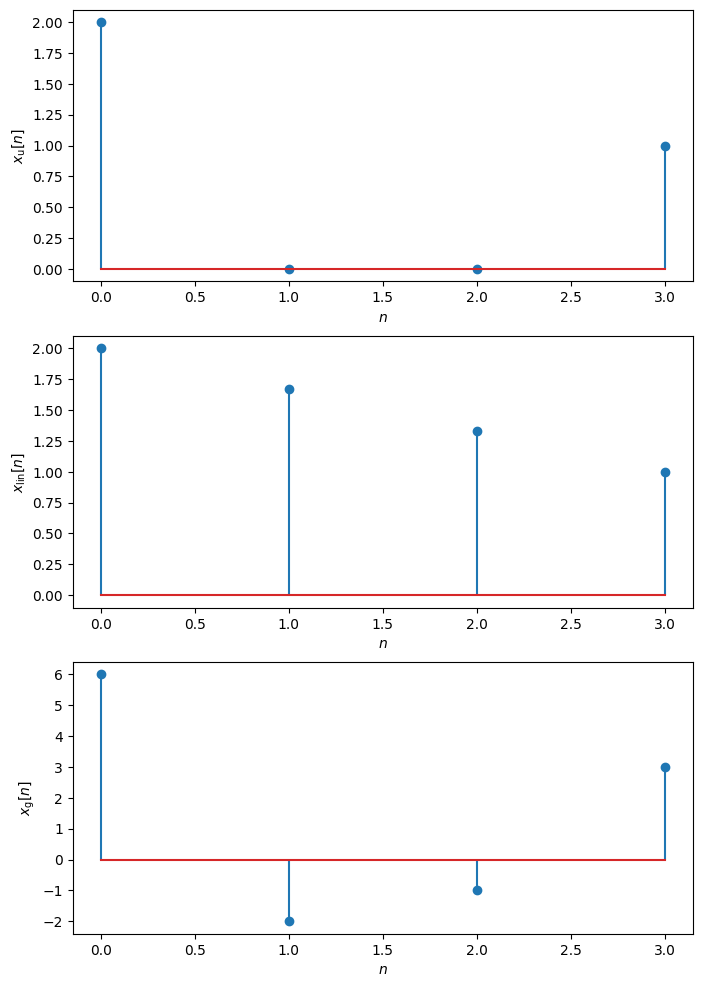

In [10]:
n_u = np.arange(0, 4, 1)
x_u = [2, 0, 0, 1]
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
ax[0].stem(n_u, x_u)
ax[0].set_xlabel('$n$')
ax[0].set_ylabel('$x_{\\text{u}}[n]$')

x_g_lin = [2, 5/3, 4/3, 1]
ax[1].stem(n_u, x_g_lin)
ax[1].set_xlabel('$n$')
ax[1].set_ylabel('$x_{\\text{lin}}[n]$')

x_g = [6, -2, -1, 3]
ax[2].stem(n_u, x_g)
ax[2].set_xlabel('$n$')
ax[2].set_ylabel('$x_{\\text{g}}[n]$')

## Problem 4
The file `SampleRateData.dat` contains a short segment of a signal that is sampled at 1 kHz. The signal, denoted by $x[n]$, can be loaded into `MATLAB` with `x=load('SampleRateData.dat')`. In this problem we will first form the signal $y[n]$ by decimating $x[n]$ by two. Afterwards, we create the signal $z[n]$ by 'undoing' the decimation, i.e., $z[n]$ is found by interpolating $y[n]$ by two.

### 1. Perform the decimation and interpolation. Document the procedure, plot the signals at each stage, and explain the shape of the signals after decimation and after interpolation.

## Problem 5
Consider a two-channel filter bank where it is intended to operate it as a quadrature mirror
filter with $H(z) = 1 + \frac{1}{2} z^{−1}$.

### 1. Are $H_0(z)$ and $H_1(z)$ power complementary?

### 2. Will the choice of $H(z)$ lead to an aliasing-free filter bank?

### 3. Discuss the choice of $H(z)$ for a quadrature mirror filter bank.

## Problem 6
The file `dataset.dat` contains 2048 samples of an unknown signal. The signal can be loaded
into `MATLAB` with `x=load('dataset.dat')`.

### 1. Compute and plot the autocorrelation for an appropriate range of lags. Compare it with the autocorrelation for an equal length realization of white Gaussion noise with the same power. What can be derived about the signal in the file from the autocorrelation? 

### 2. Estimate and plot the power spectral density of the signal using first a periodogram and second Welch's method. Discuss the results and explain the pros and cons of the two methods.